In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
df = pd.read_csv("portfolio/results_temps_deg4.csv")

# Créer colonne method-jobtype
df["method_jobtype"] = df["method"] + "-" + df["jobtype"].astype(str)

# Grouper
grouped = df.groupby(["time limit", "method_jobtype"])["mean_relat_test"].mean().reset_index()

# Liste des time limits
time_limits = sorted(grouped["time limit"].unique())

# Palette
palette = sns.color_palette("hls", len(grouped["method_jobtype"].unique()))

for t in time_limits:
    subset = grouped[grouped["time limit"] == t].copy()
    
    # Identifier la meilleure (plus bas regret)
    best_idx = subset["mean_relat_test"].idxmin()
    best_row = subset.loc[best_idx]
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=subset,
        x="method_jobtype",
        y="mean_relat_test",
        palette=palette
    )
    
    # Titre
    plt.title(f"Mean Relative Regret – Time Limit: {int(t)} seconds")
    plt.xlabel("Method - Job Type")
    plt.ylabel("Mean Relative Regret")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    
    # Annoter la meilleure barre
    for i, bar in enumerate(ax.patches):
        val = subset.iloc[i]["mean_relat_test"]
        label = f"{val:.3f}"
        if i == list(subset.index).index(best_idx):
            # En gras pour la meilleure
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f"**{label}**",
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color='black'
            )
        else:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                label,
                ha='center',
                va='bottom',
                fontsize=8,
                color='gray'
            )
    
    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'portfolio/results_temps_deg4.csv'

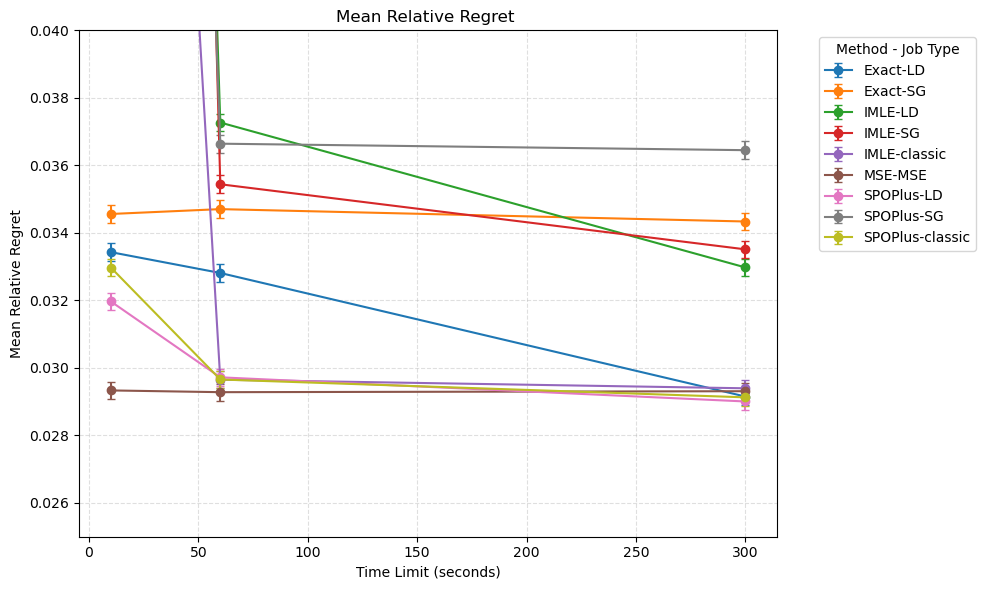

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Charger les données
df = pd.read_csv("portfolio/results_temps_deg8.csv")
df_muloss = pd.read_csv("portfolio/results_temps_deg8_muloss_0.csv")

# Créer identifiant méthode-type
df["method_jobtype"] = df["method"] + "-" + df["jobtype"].astype(str)

# Calcul de l'intervalle de confiance 95 %
df["ci95"] = 1.96 * df["std_relat_test"] / np.sqrt(10000)

# Moyenne et CI groupées
grouped = df.groupby(["method_jobtype", "time limit"]).agg(
    mean=("mean_relat_test", "mean"),
    ci95=("ci95", "mean")
).reset_index()

# Palette
palette = sns.color_palette("tab10", n_colors=grouped["method_jobtype"].nunique())

# Tracer les courbes avec barres d'erreur
plt.figure(figsize=(10, 6))
for i, (name, group) in enumerate(grouped.groupby("method_jobtype")):
    group = group.sort_values("time limit")
    plt.errorbar(
        group["time limit"],
        group["mean"],
        yerr=group["ci95"],
        label=name,
        marker='o',
        capsize=3,
        linestyle='-',
        color=palette[i]
    )

plt.title("Mean Relative Regret ")
plt.xlabel("Time Limit (seconds)")
plt.ylabel("Mean Relative Regret")
plt.ylim(0.025, 0.04)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Method - Job Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def filter_dataframe(csv_path, time_limit, method, jobtype, step_mu, n_iter_mu, suffix=""):
    """
    Filtre un CSV selon les paramètres donnés et retourne un DataFrame avec CI95.
    Un suffixe peut être ajouté à l'identifiant méthode-jobtype.
    """
    df = pd.read_csv(csv_path)

    filtered = df[
        (df["time limit"] == time_limit) &
        (df["method"] == method) &
        (df["jobtype"] == jobtype) &
        (df["step_mu"] == step_mu) &
        (df["n_iter_mu"] == n_iter_mu)
    ].copy()

    if filtered.empty:
        print(f"[WARN] Aucune ligne trouvée pour : {method}-{jobtype}{suffix} @ {time_limit}s")
        return filtered

    # Ajouter identifiant unique avec suffixe
    filtered["method_jobtype"] = f"{method}-{jobtype}{suffix}"
    
    # Ajouter CI 95 %
    filtered["ci95"] = 1.96 * filtered["std_relat_test"] / np.sqrt(10000)

    return filtered


def merge_dataframes(df_list):
    """
    Fusionne plusieurs DataFrames filtrés.
    """
    return pd.concat(df_list, ignore_index=True)


def plot_mean_regret_with_ci(df, title="Mean Relative Regret with 95% CI"):
    """
    Trace le graphique avec moyenne + intervalle de confiance.
    """
    grouped = df.groupby(["method_jobtype", "time limit"]).agg(
        mean=("mean_relat_test", "mean"),
        ci95=("ci95", "mean")
    ).reset_index()

    unique_labels = grouped["method_jobtype"].unique()
    colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(unique_labels)))

    plt.figure(figsize=(10, 6))
    for i, label in enumerate(unique_labels):
        subset = grouped[grouped["method_jobtype"] == label].sort_values("time limit")
        plt.errorbar(
            subset["time limit"],
            subset["mean"],
            yerr=subset["ci95"],
            label=label,
            marker='o',
            linestyle='-',
            capsize=3,
            color=colors[i]
        )

    plt.title(title)
    plt.xlabel("Time Limit (seconds)")
    plt.ylabel("Mean Relative Regret")
    plt.ylim(0.017, 0.026)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Method - Job Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

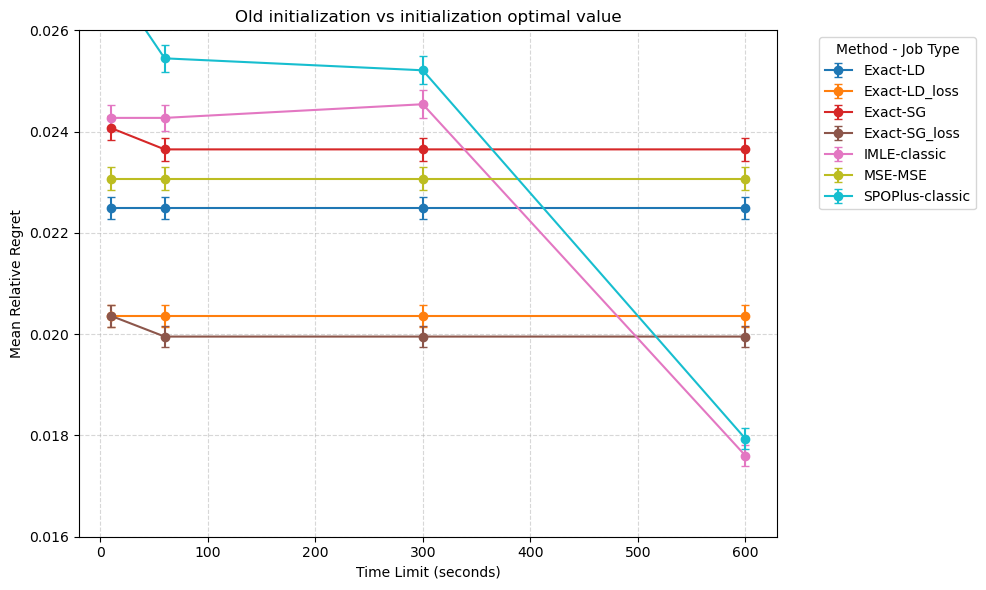

In [ ]:
# Exemple d'usage


csv = "portfolio/seed/results_seed0.csv"
csv_loss = "portfolio/seed/results_seed0_muloss.csv"
# csv_mu0 = "portfolio/results_temps_deg_8mu0.csv"

cla_IMLE_10_df = filter_dataframe(csv, 10, "IMLE", "classic", 5, 15)
cla_IMLE_60_df = filter_dataframe(csv, 60, "IMLE", "classic", 5, 15)
cla_IMLE_300_df = filter_dataframe(csv, 300, "IMLE", "classic", 5, 15)
cla_IMLE_600_df = filter_dataframe(csv, 600, "IMLE", "classic", 5, 15)
cla_SPOPlus_10_df = filter_dataframe(csv, 10, "SPOPlus", "classic", 5, 15)
cla_SPOPlus_60_df = filter_dataframe(csv, 60, "SPOPlus", "classic", 5, 15)
cla_SPOPlus_300_df = filter_dataframe(csv, 300, "SPOPlus", "classic", 5, 15)
cla_SPOPlus_600_df = filter_dataframe(csv, 600, "SPOPlus", "classic", 5, 15)
MSE_MSE_10_df = filter_dataframe(csv, 10, "MSE", "MSE", 5, 15)
MSE_MSE_60_df = filter_dataframe(csv, 60, "MSE", "MSE", 5, 15)
MSE_MSE_300_df = filter_dataframe(csv, 300, "MSE", "MSE", 5, 15)
MSE_MSE_600_df = filter_dataframe(csv, 600, "MSE", "MSE", 5, 15)
LD_Exact_10_df = filter_dataframe(csv, 10, "Exact", "LD", 5, 15)
LD_Exact_60_df = filter_dataframe(csv, 60, "Exact", "LD", 5, 15)
LD_Exact_300_df = filter_dataframe(csv, 300, "Exact", "LD", 5, 15)
LD_Exact_600_df = filter_dataframe(csv, 600, "Exact", "LD", 5, 15)
SG_Exact_10_df = filter_dataframe(csv, 10, "Exact", "SG", 20, 10)
SG_Exact_60_df = filter_dataframe(csv, 60, "Exact", "SG", 20, 20)
SG_Exact_300_df = filter_dataframe(csv, 300, "Exact", "SG", 20, 20)
SG_Exact_600_df = filter_dataframe(csv, 600, "Exact", "SG", 20, 20)

LD_Exact_10_loss_df = filter_dataframe(csv_loss, 10, "Exact", "LD", 5, 15, suffix="_loss")
LD_Exact_60_loss_df = filter_dataframe(csv_loss, 60, "Exact", "LD", 5, 15, suffix="_loss")
LD_Exact_300_loss_df = filter_dataframe(csv_loss, 300, "Exact", "LD", 5, 15, suffix="_loss")
LD_Exact_600_loss_df = filter_dataframe(csv_loss, 600, "Exact", "LD", 5, 15, suffix="_loss")
SG_Exact_10_loss_df = filter_dataframe(csv_loss, 10, "Exact", "SG", 20, 10, suffix="_loss")
SG_Exact_60_loss_df = filter_dataframe(csv_loss, 60, "Exact", "SG", 20, 20, suffix="_loss")
SG_Exact_300_loss_df = filter_dataframe(csv_loss, 300, "Exact", "SG", 20, 20, suffix="_loss")
SG_Exact_600_loss_df = filter_dataframe(csv_loss, 600, "Exact", "SG", 20, 20, suffix="_loss")

# SG_SPOPlus_10_df = filter_dataframe(csv, 10, "SPOPlus", "SG", 10, 10)
# SG_SPOPlus_60_df = filter_dataframe(csv, 60, "SPOPlus", "SG", 10, 10)
# SG_SPOPlus_300_df = filter_dataframe(csv, 300, "SPOPlus", "SG", 5, 10)
# SG_IMLE_10_df = filter_dataframe(csv, 10, "IMLE", "SG", 10, 10)
# SG_IMLE_60_df = filter_dataframe(csv, 60, "IMLE", "SG", 10, 10)
# SG_IMLE_300_df = filter_dataframe(csv, 300, "IMLE", "SG", 5, 10)

# SG_SPOPlus_10_mu0_df = filter_dataframe(csv_mu0, 10, "SPOPlus", "SG", 20, 10, suffix="_mu0")
# SG_SPOPlus_60_mu0_df = filter_dataframe(csv_mu0, 60, "SPOPlus", "SG", 20, 10, suffix="_mu0")
# SG_SPOPlus_300_mu0_df = filter_dataframe(csv_mu0, 300, "SPOPlus", "SG", 20, 10, suffix="_mu0")
# SG_IMLE_10_mu0_df = filter_dataframe(csv_mu0, 10, "IMLE", "SG", 20, 10, suffix="_mu0")
# SG_IMLE_60_mu0_df = filter_dataframe(csv_mu0, 60, "IMLE", "SG", 20, 10, suffix="_mu0")
# SG_IMLE_300_mu0_df = filter_dataframe(csv_mu0, 300, "IMLE", "SG", 20, 10, suffix="_mu0")
# SG_Exact_10_mu0_df = filter_dataframe(csv_mu0, 10, "Exact", "SG", 20, 10, suffix="_mu0")
# SG_Exact_60_mu0_df = filter_dataframe(csv_mu0, 60, "Exact", "SG", 20, 10, suffix="_mu0")
# SG_Exact_300_mu0_df = filter_dataframe(csv_mu0, 300, "Exact", "SG", 20, 10, suffix="_mu0")


# Fusionner
merged_df = merge_dataframes([
    cla_IMLE_10_df, cla_IMLE_60_df, cla_IMLE_300_df, cla_IMLE_600_df,
    cla_SPOPlus_10_df, cla_SPOPlus_60_df, cla_SPOPlus_300_df, cla_SPOPlus_600_df,
    MSE_MSE_10_df, MSE_MSE_60_df, MSE_MSE_300_df, MSE_MSE_600_df,
    LD_Exact_10_df, LD_Exact_60_df, LD_Exact_300_df, LD_Exact_600_df,
    SG_Exact_10_df, SG_Exact_60_df, SG_Exact_300_df, SG_Exact_600_df,
    LD_Exact_10_loss_df, LD_Exact_60_loss_df, LD_Exact_300_loss_df, LD_Exact_600_loss_df,
    SG_Exact_10_loss_df, SG_Exact_60_loss_df, SG_Exact_300_loss_df, SG_Exact_600_loss_df,
    # SG_SPOPlus_10_df, SG_SPOPlus_60_df, SG_SPOPlus_300_df,
    # SG_IMLE_10_df, SG_IMLE_60_df, SG_IMLE_300_df,
    # SG_SPOPlus_10_mu0_df, SG_SPOPlus_60_mu0_df, SG_SPOPlus_300_mu0_df,
    # SG_IMLE_10_mu0_df, SG_IMLE_60_mu0_df, SG_IMLE_300_mu0_df,
    # SG_Exact_10_mu0_df, SG_Exact_60_mu0_df, SG_Exact_300_mu0_df,
])

#plot
plot_mean_regret_with_ci(merged_df, title="Old initialization vs initialization optimal value")

In [ ]:
def filter_dataframe_multi_seed(base_path, seeds, time_limit, method, jobtype, step_mu, n_iter_mu, suffix=""):
    """
    Charge les CSV de plusieurs seeds, filtre chaque dataframe, et agrège les regrets relatifs pour moyenne globale + IC95.
    """
    rows = []
    for seed in seeds:
        path = base_path.replace("seed0", f"seed{seed}")
        try:
            df = pd.read_csv(path)
        except FileNotFoundError:
            print(f"[WARN] Fichier introuvable : {path}")
            continue

        filtered = df[
            (df["time limit"] == time_limit) &
            (df["method"] == method) &
            (df["jobtype"] == jobtype) &
            (df["step_mu"] == step_mu) &
            (df["n_iter_mu"] == n_iter_mu)
        ]

        if filtered.empty:
            print(f"[WARN] Aucun résultat pour seed {seed} avec {method}-{jobtype}{suffix} @ {time_limit}s")
            continue

        rows.append(filtered["mean_relat_test"].values[0])  # on stocke la valeur moyenne

    if len(rows) == 0:
        return pd.DataFrame()  # vide si aucun seed valide

    rows = np.array(rows)
    df_result = pd.DataFrame({
        "time limit": [time_limit],
        "method": [method],
        "jobtype": [jobtype],
        "step_mu": [step_mu],
        "n_iter_mu": [n_iter_mu],
        "mean_relat_test": [rows.mean()],
        "ci95": [1.96 * rows.std(ddof=1) / np.sqrt(len(rows))],
        "method_jobtype": [f"{method}-{jobtype}{suffix}"]
    })
    return df_result

def plot_mean_regret_with_ci(df, title="Mean Relative Regret with 95% CI"):
    """
    Trace le graphique avec moyenne + intervalle de confiance.
    """
    grouped = df.groupby(["method_jobtype", "time limit"]).agg(
        mean=("mean_relat_test", "mean"),
        ci95=("ci95", "mean")
    ).reset_index()

    unique_labels = grouped["method_jobtype"].unique()
    colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(unique_labels)))

    plt.figure(figsize=(10, 6))
    for i, label in enumerate(unique_labels):
        subset = grouped[grouped["method_jobtype"] == label].sort_values("time limit")
        plt.errorbar(
            subset["time limit"],
            subset["mean"],
            yerr=subset["ci95"],
            label=label,
            marker='o',
            linestyle='-',
            capsize=3,
            color=colors[i]
        )

    plt.title(title)
    plt.xlabel("Time Limit (seconds)")
    plt.ylabel("Mean Relative Regret")
    plt.ylim(0.019, 0.0245)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Method - Job Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

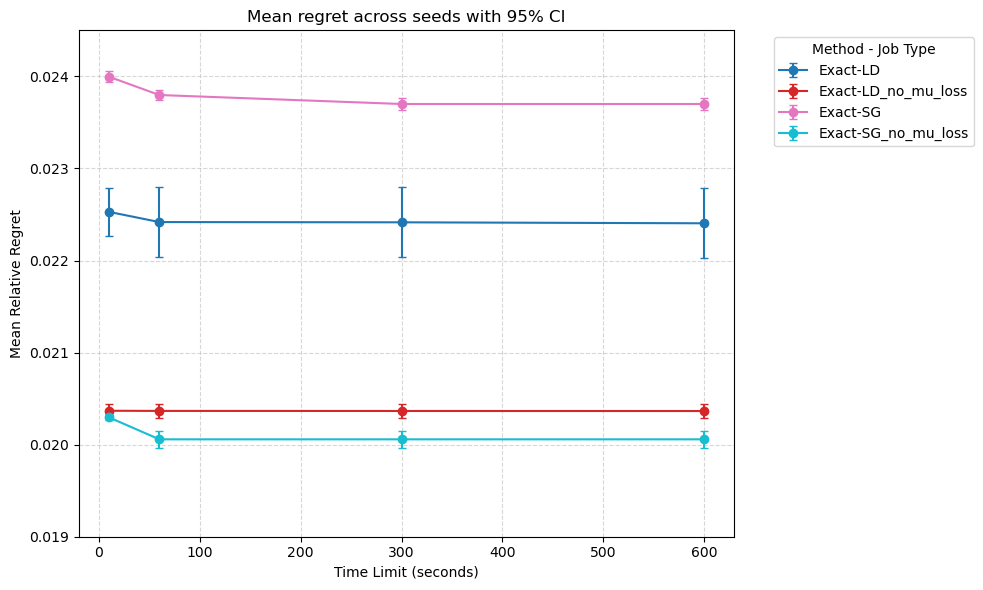

In [ ]:
seeds = list(range(10))
csv_base = "portfolio/seed/results_seed0.csv"
csv_base_loss = "portfolio/seed/results_seed0_muloss.csv"

cla_IMLE_dfs = [
    filter_dataframe_multi_seed(csv_base, seeds, t, "IMLE", "classic", 5, 15)
    for t in [10, 60, 300, 600]
]
cla_SPOPlus_dfs = [
    filter_dataframe_multi_seed(csv_base, seeds, t, "SPOPlus", "classic", 5, 15)
    for t in [10, 60, 300, 600]
]

MSE_MSE_dfs = [
    filter_dataframe_multi_seed(csv_base, seeds, t, "MSE", "MSE", 5, 15)
    for t in [10, 60, 300, 600]
]
LD_Exact_dfs = [
    filter_dataframe_multi_seed(csv_base, seeds, t, "Exact", "LD", 5, 15)
    for t in [10, 60, 300, 600]
]
SG_Exact_dfs = [
    filter_dataframe_multi_seed(csv_base, seeds, 10, "Exact", "SG", 20, 10)
] + [
    filter_dataframe_multi_seed(csv_base, seeds, t, "Exact", "SG", 20, 20)
    for t in [60, 300, 600]
]
LD_Exact_loss_dfs = [
    filter_dataframe_multi_seed(csv_base_loss, seeds, t, "Exact", "LD", 5, 15, suffix="_no_mu_loss")
    for t in [10, 60, 300, 600]
]
SG_Exact_loss_dfs = [
    filter_dataframe_multi_seed(csv_base_loss, seeds, 10, "Exact", "SG", 20, 10, suffix="_no_mu_loss")
] + [
    filter_dataframe_multi_seed(csv_base_loss, seeds, t, "Exact", "SG", 20, 20, suffix="_no_mu_loss")
    for t in [60, 300, 600]
]


merged_df = merge_dataframes([
    #*cla_IMLE_dfs, *cla_SPOPlus_dfs,
    #*MSE_MSE_dfs,
    *LD_Exact_dfs, *SG_Exact_dfs,
    *LD_Exact_loss_dfs, *SG_Exact_loss_dfs
])
plot_mean_regret_with_ci(merged_df, title="Mean regret across seeds with 95% CI")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def filter_dataframe(csv_path, time_limit, method, jobtype, step_mu, n_iter_mu, suffix=""):
    """
    Filtre un CSV selon les paramètres donnés et retourne un DataFrame avec CI95.
    Un suffixe peut être ajouté à l'identifiant méthode-jobtype.
    """
    df = pd.read_csv(csv_path)

    filtered = df[
        (df["time limit"] == time_limit) &
        (df["method"] == method) &
        (df["jobtype"] == jobtype) &
        (df["step_mu"] == step_mu) &
        (df["num_iter_mu"] == n_iter_mu)
    ].copy()

    if filtered.empty:
        print(f"[WARN] Aucune ligne trouvée pour : {method}-{jobtype}{suffix} @ {time_limit}s")
        return filtered

    # Ajouter identifiant unique avec suffixe
    filtered["method_jobtype"] = f"{method}-{jobtype}{suffix}"
    
    # Ajouter CI 95 %
    filtered["ci95"] = 1.96 * filtered["std_relat_test"] / np.sqrt(10000)

    return filtered


def merge_dataframes(df_list):
    """
    Fusionne plusieurs DataFrames filtrés.
    """
    return pd.concat(df_list, ignore_index=True)


def plot_mean_regret_with_ci(df, title="Mean Relative Regret with 95% CI"):
    """
    Trace le graphique avec moyenne + intervalle de confiance.
    """
    grouped = df.groupby(["method_jobtype", "time limit"]).agg(
        mean=("mean_relat_test", "min"),
        ci95=("ci95", "mean")
    ).reset_index()

    unique_labels = grouped["method_jobtype"].unique()
    colors = plt.get_cmap("tab10")(np.linspace(0, 1, len(unique_labels)))

    plt.figure(figsize=(10, 6))
    for i, label in enumerate(unique_labels):
        subset = grouped[grouped["method_jobtype"] == label].sort_values("time limit")
        plt.errorbar(
            subset["time limit"],
            subset["mean"],
            yerr=subset["ci95"],
            label=label,
            marker='o',
            linestyle='-',
            capsize=3,
            color=colors[i]
        )

    plt.title(title)
    plt.xlabel("Time Limit (seconds)")
    plt.ylabel("Mean Relative Regret")
    plt.ylim(0.05, 0.35)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Method - Job Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

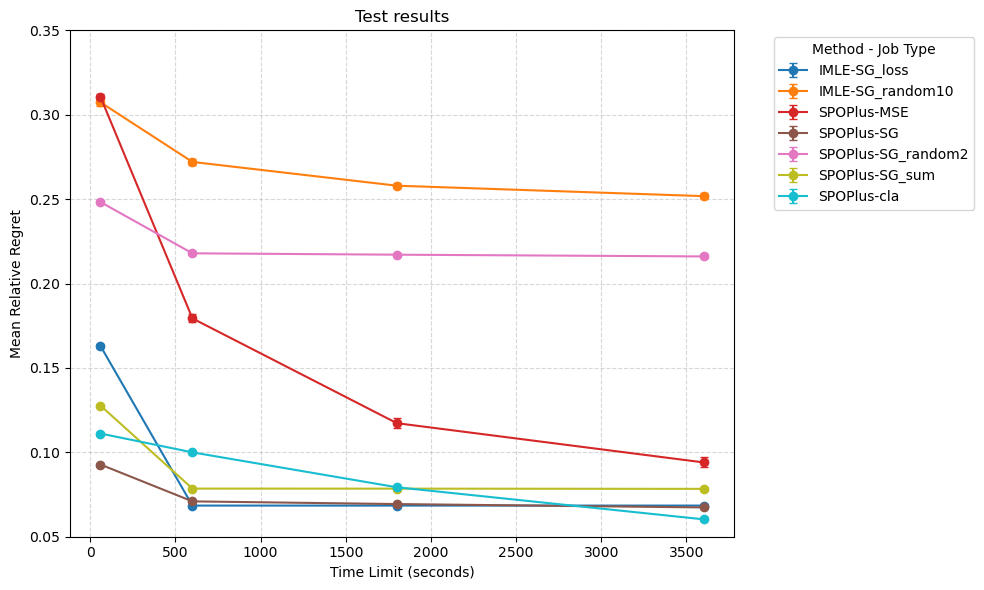

In [ ]:

csv = "knapsack/seed/results_seed0.csv"
csv_loss = "knapsack/seed/results_seed0_muloss.csv"
csv_mains1 = "knapsack/seed/results_seed0_mains1.csv"
csv_mains0_1 = "knapsack/seed/results_seed0_mains_01.csv"
csv_mains_sum = "knapsack/seed/results_seed0_mains_sum.csv"
csv_mains = "knapsack/seed/results_seed0_mains.csv"

cla_IMLE_60_df    = filter_dataframe(csv, 60, "IMLE", "cla", 1, 10)
cla_IMLE_600_df   = filter_dataframe(csv, 600, "IMLE", "cla", 1, 10)
cla_IMLE_1800_df  = filter_dataframe(csv, 1800, "IMLE", "cla", 1, 10)
cla_IMLE_3600_df  = filter_dataframe(csv, 3600, "IMLE", "cla", 1, 10)

cla_SPOPlus_60_df    = filter_dataframe(csv, 60, "SPOPlus", "cla", 5, 5)
cla_SPOPlus_600_df   = filter_dataframe(csv, 600, "SPOPlus", "cla", 5, 5)
cla_SPOPlus_1800_df  = filter_dataframe(csv, 1800, "SPOPlus", "cla", 5, 5)
cla_SPOPlus_3600_df  = filter_dataframe(csv, 3600, "SPOPlus", "cla", 5, 5)

MSE_MSE_60_df    = filter_dataframe(csv, 60, "SPOPlus", "MSE", 5, 5)
MSE_MSE_600_df   = filter_dataframe(csv, 600, "SPOPlus",  "MSE", 5, 5)
MSE_MSE_1800_df  = filter_dataframe(csv, 1800, "SPOPlus",  "MSE", 5, 5)
MSE_MSE_3600_df  = filter_dataframe(csv, 3600, "SPOPlus", "MSE", 5, 5)

SG_IMLE_60_df    = filter_dataframe(csv, 60, "IMLE", "SG", 10, 5)
SG_SPOPlus_60_df    = filter_dataframe(csv, 60, "SPOPlus", "SG", 20, 10)
SG_IMLE_600_df   = filter_dataframe(csv, 600, "IMLE", "SG", 5, 5)
SG_SPOPlus_600_df   = filter_dataframe(csv, 600, "SPOPlus", "SG", 10, 10)
SG_IMLE_1800_df  = filter_dataframe(csv, 1800, "IMLE", "SG", 5, 5)
SG_SPOPlus_1800_df  = filter_dataframe(csv, 1800, "SPOPlus", "SG", 10, 10)
SG_IMLE_3600_df  = filter_dataframe(csv, 3600, "IMLE", "SG", 5, 5)
SG_SPOPlus_3600_df  = filter_dataframe(csv, 3600, "SPOPlus", "SG", 10, 10)

SG_IMLE_60_loss_df    = filter_dataframe(csv_loss, 60, "IMLE", "SG", 20, 10, suffix="_loss")
SG_IMLE_600_loss_df   = filter_dataframe(csv_loss, 600, "IMLE", "SG", 5, 10, suffix="_loss")
SG_IMLE_1800_loss_df  = filter_dataframe(csv_loss, 1800, "IMLE", "SG", 5, 10, suffix="_loss")
SG_IMLE_3600_loss_df  = filter_dataframe(csv_loss, 3600, "IMLE", "SG", 5, 10, suffix="_loss")

SG_IMLE_60_mains0_1 = filter_dataframe(csv_mains_sum, 60, "IMLE", "SG", 20, 5, suffix="_sum")
SG_IMLE_600_mains0_1 = filter_dataframe(csv_mains_sum, 600, "IMLE", "SG", 5, 10, suffix="_sum")
SG_IMLE_1800_mains0_1 = filter_dataframe(csv_mains_sum, 1800, "IMLE", "SG", 5, 10, suffix="_sum")
SG_IMLE_3600_mains0_1 = filter_dataframe(csv_mains_sum, 3600, "IMLE", "SG", 5, 10, suffix="_sum")
SG_SPOPlus_60_mains0_1 = filter_dataframe(csv_mains_sum, 60, "SPOPlus", "SG", 20, 5, suffix="_sum")
SG_SPOPlus_600_mains0_1 = filter_dataframe(csv_mains_sum, 600, "SPOPlus", "SG", 5, 10, suffix="_sum")
SG_SPOPlus_1800_mains0_1 = filter_dataframe(csv_mains_sum, 1800, "SPOPlus", "SG", 5, 10, suffix="_sum")
SG_SPOPlus_3600_mains0_1 = filter_dataframe(csv_mains_sum, 3600, "SPOPlus", "SG", 5, 10, suffix="_sum")

SG_IMLE_60_mains1_df = filter_dataframe(csv_mains0_1, 60, "IMLE", "SG", 20, 10, suffix="_random2")
SG_IMLE_600_mains1_df = filter_dataframe(csv_mains0_1, 600, "IMLE", "SG", 1, 5, suffix="_random2")
SG_IMLE_1800_mains1_df = filter_dataframe(csv_mains0_1, 1800, "IMLE", "SG", 1, 5, suffix="_random2")
SG_IMLE_3600_mains1_df = filter_dataframe(csv_mains0_1, 3600, "IMLE", "SG", 1, 5, suffix="_random2")
SG_SPOPlus_60_mains1_df = filter_dataframe(csv_mains0_1, 60, "SPOPlus", "SG", 10, 5, suffix="_random2")
SG_SPOPlus_600_mains1_df = filter_dataframe(csv_mains0_1, 600, "SPOPlus", "SG", 5, 20, suffix="_random2")
SG_SPOPlus_1800_mains1_df = filter_dataframe(csv_mains0_1, 1800, "SPOPlus", "SG", 5, 20, suffix="_random2")
SG_SPOPlus_3600_mains1_df = filter_dataframe(csv_mains0_1, 3600, "SPOPlus", "SG", 5, 20, suffix="_random2")

SG_IMLE_60_mains_df = filter_dataframe(csv_mains, 60, "IMLE", "SG", 20, 5, suffix="_random10")
SG_IMLE_600_mains_df = filter_dataframe(csv_mains, 600, "IMLE", "SG", 5, 5, suffix="_random10")
SG_IMLE_1800_mains_df = filter_dataframe(csv_mains, 1800, "IMLE", "SG", 5, 20, suffix="_random10")
SG_IMLE_3600_mains_df = filter_dataframe(csv_mains, 3600, "IMLE", "SG", 5, 20, suffix="_random10")


# fusionner
merged_knapsack_df = merge_dataframes([
    # cla_IMLE_60_df, cla_IMLE_600_df, cla_IMLE_1800_df, cla_IMLE_3600_df,
    cla_SPOPlus_60_df, cla_SPOPlus_600_df, cla_SPOPlus_1800_df, cla_SPOPlus_3600_df,
    MSE_MSE_60_df, MSE_MSE_600_df, MSE_MSE_1800_df, MSE_MSE_3600_df,
    # SG_IMLE_60_df, SG_IMLE_600_df, SG_IMLE_1800_df, SG_IMLE_3600_df,
    SG_SPOPlus_60_df, SG_SPOPlus_600_df, SG_SPOPlus_1800_df, SG_SPOPlus_3600_df,
    SG_IMLE_60_loss_df, SG_IMLE_600_loss_df, SG_IMLE_1800_loss_df, SG_IMLE_3600_loss_df,
    # SG_IMLE_60_mains0_1, SG_IMLE_600_mains0_1, SG_IMLE_1800_mains0_1, SG_IMLE_3600_mains0_1,
    SG_SPOPlus_60_mains0_1, SG_SPOPlus_600_mains0_1, SG_SPOPlus_1800_mains0_1, SG_SPOPlus_3600_mains0_1,
    # SG_IMLE_60_mains1_df, SG_IMLE_600_mains1_df, SG_IMLE_1800_mains1_df, SG_IMLE_3600_mains1_df,
    SG_SPOPlus_60_mains1_df, SG_SPOPlus_600_mains1_df, SG_SPOPlus_1800_mains1_df, SG_SPOPlus_3600_mains1_df,
    SG_IMLE_60_mains_df, SG_IMLE_600_mains_df, SG_IMLE_1800_mains_df, SG_IMLE_3600_mains_df,

])

# Tracer le graphique pour knapsack
plot_mean_regret_with_ci(merged_knapsack_df, title="Test results")






# Nouveaux tests


In [ ]:
import pandas as pd

# 1. Charger votre CSV
df = pd.read_csv("portfolio/n50/results_hyper_seed0.csv")


# 2. S’assurer que les NaN de ‘method’ et ‘jobtype’ sont bien considérés comme des clés de groupe
df["method"]  = df["method"].fillna("")   # remplace NaN par chaîne vide
df["jobtype"] = df["jobtype"].fillna("")

# 3. Grouper par cp, method, jobtype, muloss (dropna=False pour inclure les NaN transformés)
best_idx = df.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

# 4. Extraire les hyper-paramètres optimaux pour chaque (cp, method, jobtype, muloss)
best_params = (
    df
    .loc[best_idx, ["cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu", "mean_relat_eval"]]
    .reset_index(drop=True)
)

print(best_params)

      cp   method  jobtype  muloss     lr  step_mu  num_iter_mu  \
0     10               MSE    True  0.100        0            0   
1     10    Exact       LD   False  0.050        0            0   
2     10    Exact       LD    True  0.010        0            0   
3     10    Exact       SG   False  0.100       15            5   
4     10    Exact       SG    True  0.100       20           30   
5     10     IMLE  classic    True  1.000        0            0   
6     10  SPOPlus       LD    True  0.010        0            0   
7     10  SPOPlus       SG    True  0.100       15            1   
8     10  SPOPlus  classic    True  0.010        0            0   
9     60               MSE    True  0.100        0            0   
10    60    Exact       LD   False  0.050        0            0   
11    60    Exact       LD    True  0.010        0            0   
12    60    Exact       SG   False  0.100       15            5   
13    60    Exact       SG    True  0.100       20           3

In [ ]:
import os
import pandas as pd

# ------------------------------------------------------------------
# 2) Dictionnaires utilitaires
# ------------------------------------------------------------------
EP_SUFFIX = {
    "classic": "cla",
    "cla":     "cla",
    "LD":      "ld",
    "SG":      "sg",
    "mse":     "mse",
    "MSE":     "mse",
}
NAME_SUFFIX = {
    "classic": "cla",
    "cla":     "cla",
    "LD":      "LD",
    "SG":      "SG",
    "mse":     "mse",
    "MSE":     "mse",
}

JOB_DIR = "portfolio/jobs_50"
os.makedirs(JOB_DIR, exist_ok=True)

# ------------------------------------------------------------------
# 3) Conversion lr float → chaîne "0p0001"
# ------------------------------------------------------------------
def lr_to_str(lr: float) -> str:
    return str(lr).replace(".", "p")

# ------------------------------------------------------------------
# 4) Génération des scripts SLURM pour seeds 0 à 9
# ------------------------------------------------------------------
for _, row in best_params.iterrows():
    n         = row.get("n", 50)
    jobtype   = str(row["jobtype"])
    method    = str(row["method"]).strip()
    muloss    = row.get("muloss", True)
    lr        = row["lr"]
    step_mu   = int(row.get("step_mu", 0))
    n_iter_mu = int(row.get("num_iter_mu", 0))

    # Pour MSE, on force la méthode à IMLE
    if jobtype.lower() == "mse":
        method = "IMLE"
    if method == "" or method.lower() == "nan":
        method = "Exact"

    # Construction des suffixes pour le nom
    jt_name = NAME_SUFFIX.get(jobtype, jobtype)
    lr_str  = lr_to_str(lr)

    # Cas step_mu / n_iter_mu
    extra_name = ""
    extra_args = ""
    if step_mu > 0 or n_iter_mu > 0:
        extra_name = f"_sm{step_mu}_ni{n_iter_mu}"
        extra_args = f" --step_mu {step_mu} --n_iter_mu {n_iter_mu}"

    # Argument --ep_*
    ep_suffix = EP_SUFFIX.get(jobtype, "")
    ep_arg    = f"--ep_{ep_suffix} 1000000" if ep_suffix else ""

    # Argument --muloss
    muloss_arg = "" if bool(muloss) else "--muloss 0"

    # Boucle sur les seeds 0 à 9
    for seed in range(10):
        # Nom du job SLURM incluant le seed
        job_name = f"portfolio_{jt_name}_{method}_n{n}{extra_name}_lr{lr_str}_seed{seed}"

        # Outfile variant selon le seed
        out_file = f"portfolio/n50/results_seed{seed}.csv"

        # Construction du script bash
        script = f"""#!/bin/bash
#SBATCH --time=02:00:00
#SBATCH --account=def-qcappart
#SBATCH --cpus-per-task=1
#SBATCH --mem=4G
#SBATCH --job-name={job_name}
#SBATCH --output=logs/{job_name}.out
#SBATCH --error=logs/{job_name}.err

module load StdEnv/2023 cuda/12.2 python/3.10 scipy-stack
source ~/env_projet/bin/activate

python -m portfolio.run_experiments \\
  --n {n} {ep_arg}{extra_args} \\
  --lr {lr} \\
  --method {method} \\
  --seed {seed} \\
  --report 10 60 300 600 1800 3600 --num_eval_per_cp 500\\
  --out_file {out_file} \\
  {muloss_arg}
"""

        # Écriture du fichier .sh
        path = os.path.join(JOB_DIR, f"{job_name}.sh")
        with open(path, "w") as f:
            f.write(script)

        print(f"✓ Généré : {path}")

✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed0.sh
✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed1.sh
✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed2.sh
✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed3.sh
✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed4.sh
✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed5.sh
✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed6.sh
✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed7.sh
✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed8.sh
✓ Généré : portfolio/jobs_50/portfolio_mse_IMLE_n50_lr0p1_seed9.sh
✓ Généré : portfolio/jobs_50/portfolio_LD_Exact_n50_lr0p05_seed0.sh
✓ Généré : portfolio/jobs_50/portfolio_LD_Exact_n50_lr0p05_seed1.sh
✓ Généré : portfolio/jobs_50/portfolio_LD_Exact_n50_lr0p05_seed2.sh
✓ Généré : portfolio/jobs_50/portfolio_LD_Exact_n50_lr0p05_seed3.sh
✓ Généré : portfolio/jobs_50/portfolio_LD_Exact_n50_lr0p05

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── 1) Extraire best_params depuis seed0 ─────────────────────────────
df0 = pd.read_csv("portfolio/n50/results_hyper_seed0.csv")
df0["method"]  = df0["method"].fillna("")
df0["jobtype"] = df0["jobtype"].fillna("")

best_idx = df0.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

best_params = df0.loc[best_idx, [
    "cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu"
]].reset_index(drop=True)

# ─── 2) Charger tous les résultats pour seeds 0–9 ──────────────────────
all_results = []
for seed in range(10):
    path = f"portfolio/n50/results_seed{seed}.csv"
    df = pd.read_csv(path)
    df["seed"]    = seed
    df["method"]  = df["method"].fillna("")
    df["jobtype"] = df["jobtype"].fillna("")
    all_results.append(df)
results = pd.concat(all_results, ignore_index=True)

# merge_cols défini comme avant
merge_cols = ["cp","method","jobtype","muloss","lr","step_mu","num_iter_mu"]

# 1) fusionner résultats et best_params
filtered_ = pd.merge(results, best_params, on=merge_cols, how="inner")

# 2) garder, pour chaque (merge_cols + seed), l'index du min mean_relat_test
idx_min = (
    filtered_
    .groupby(merge_cols + ["seed"])["mean_relat_test"]
    .idxmin()
)

# 3) extraire ces lignes uniques
filtered = filtered_.loc[idx_min].reset_index(drop=True)

# ─── 4) Calculer stats (mean, sem, ci95) par triplet et par cp ────────
stats = (
    filtered
    .groupby(["jobtype","method","muloss","cp"])["mean_relat_test"]
    .agg(mean="mean", sem="sem")
    .reset_index()
)
stats["ci95"] = 1.96 * stats["sem"]


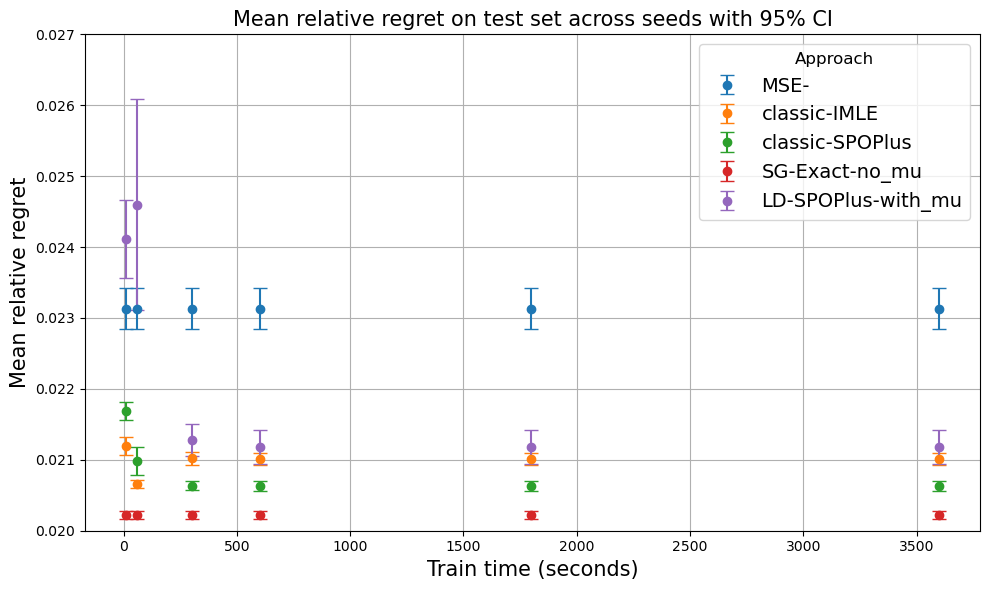

In [ ]:
# ─── 5) Sélectionner les triplets à tracer ─────────────────────────────
# Exemple : on ne trace que deux configurations
selected = [
    ("MSE",    "",  True),
    ("classic", "IMLE", True),
    ("classic", "SPOPlus", True),
    #("LD",     "Exact", True),
    #("LD",    "Exact", False),
    #("SG",     "Exact", True),
    ("SG",    "Exact", False),
    ("LD", "SPOPlus", True),
    #("SG", "SPOPlus", True),
    # ajoute ici autant de triplets que tu veux
]

# ─── 6) Tracer ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

for jt, meth, mu in selected:
    grp = stats[
        (stats["jobtype"] == jt) &
        (stats["method"]  == meth) &
        (stats["muloss"]  == mu)
    ]
    if grp.empty:
        print(f"⚠️ Aucun point pour le triplet {(jt, meth, mu)}")
        continue
    if jt in ("LD", "SG"):
        label = f"{jt}-{meth}{'-no_mu' if not mu else '-with_mu'}"
    else:
        label = f"{jt}-{meth}"
    plt.errorbar(
        grp["cp"],
        grp["mean"],
        yerr=grp["ci95"],
        fmt="o",      # marqueurs 'o' avec ligne en tirets
        capsize=5,
        label=label
    )

plt.xlabel("Train time (seconds)", fontsize=15)
plt.ylabel("Mean relative regret", fontsize=15)
plt.ylim(0.020, 0.027)
plt.title("Mean relative regret on test set across seeds with 95% CI", fontsize=15)
plt.legend(
    title="Approach",
    loc="best",
    frameon=True,
    fontsize=14,
    title_fontsize=12
)
plt.grid(True)
plt.tight_layout()
plt.show()

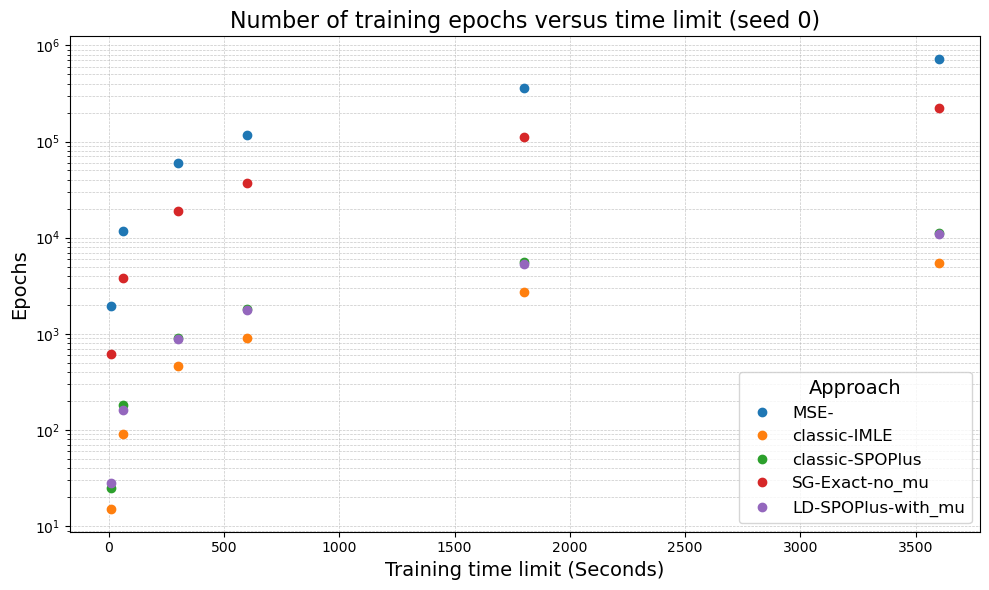

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ─── 1) Extraire best_params depuis results_hyper_seed0.csv ───────────
df0 = pd.read_csv("portfolio/n50/results_hyper_seed0.csv")
df0["method"]  = df0["method"].fillna("")
df0["jobtype"] = df0["jobtype"].fillna("")

best_idx = df0.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

best_params = df0.loc[best_idx, [
    "cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu"
]].reset_index(drop=True)

# ─── 2) Charger les résultats pour seed 0 ──────────────────────────────
df_seed0 = pd.read_csv("portfolio/n50/results_seed0.csv")
df_seed0["method"]  = df_seed0["method"].fillna("")
df_seed0["jobtype"] = df_seed0["jobtype"].fillna("")

# ─── 3) Filtrer seed0 sur les meilleures configs ───────────────────────
merge_cols = ["cp","method","jobtype","muloss","lr","step_mu","num_iter_mu"]
filtered0 = pd.merge(df_seed0, best_params, on=merge_cols, how="inner")

# ─── 4) Définir les triplets à tracer ──────────────────────────────────
selected = [
    ("MSE",    "",  True),
    ("classic", "IMLE", True),
    ("classic", "SPOPlus", True),
    #("LD",     "Exact", True),
    #("LD",    "Exact", False),
    #("SG",     "Exact", True),
    ("SG",    "Exact", False),
    ("LD", "SPOPlus", True),
    #("SG", "SPOPlus", True),
    # ajoute ici autant de triplets que tu veux
]

# ─── 5) Tracer epoch vs train time pour seed 0 ────────────────────────
plt.figure(figsize=(10, 6))

for jt, meth, mu in selected:
    grp = filtered0[
        (filtered0["jobtype"] == jt) &
        (filtered0["method"]  == meth) &
        (filtered0["muloss"]  == mu)
    ]
    if grp.empty:
        print(f"⚠️ Aucun point pour le triplet {(jt, meth, mu)}")
        continue

    if jt in ("LD", "SG"):
        label = f"{jt}-{meth}{'-no_mu' if not mu else '-with_mu'}"
    else:
        label = f"{jt}-{meth}"

    plt.plot(
        grp["cp"],
        grp["epoch"],
        marker="o",
        linestyle="",
        label=label
    )

plt.xlabel("Training time limit (Seconds)", fontsize=14)
plt.ylabel("Epochs",          fontsize=14)
plt.title("Number of training epochs versus time limit (seed 0)", fontsize=16)

# Légende à l’intérieur
leg = plt.legend(title="Approach", loc="best", frameon=True, fontsize=12)
leg.get_title().set_fontsize(14)
plt.yscale('log')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

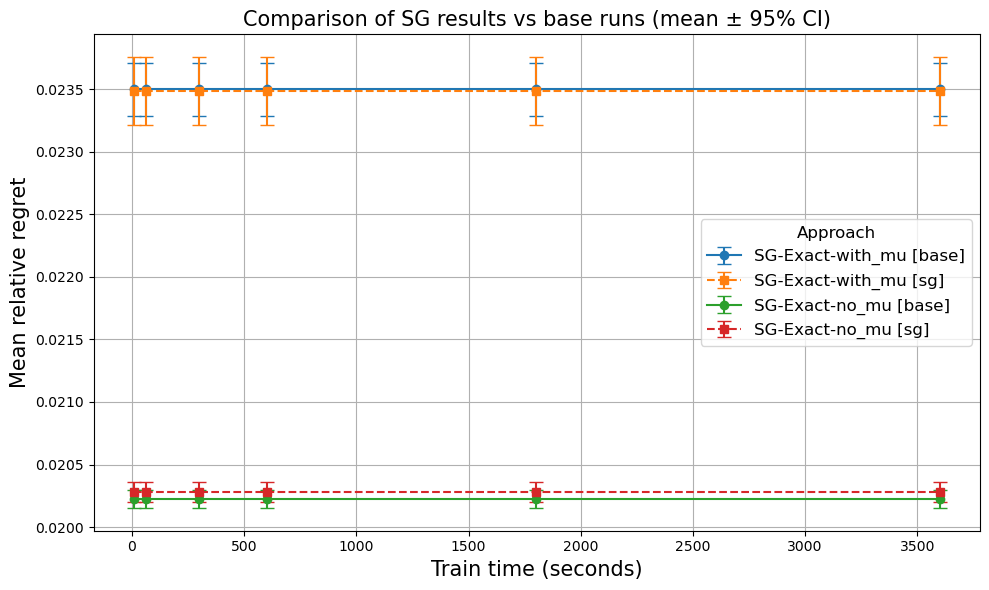

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ─── 1) Extraire best_params depuis results_hyper_seed0.csv ───────────
df0 = pd.read_csv("portfolio/n50/results_hyper_seed0.csv")
df0["method"]  = df0["method"].fillna("")
df0["jobtype"] = df0["jobtype"].fillna("")

best_idx = df0.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

best_params = df0.loc[best_idx, [
    "cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu"
]].reset_index(drop=True)

# ─── 2) Charger résultats "base" (results_seed*.csv) ───────────────────
base_list = []
for seed in range(10):
    path = f"portfolio/n50/results_seed{seed}.csv"
    if not os.path.exists(path):
        print(f"⚠️ Fichier manquant : {path} (ignoré)")
        continue
    df = pd.read_csv(path)
    df["seed"]    = seed
    df["source"]  = "base"
    df["method"]  = df["method"].fillna("")
    df["jobtype"] = df["jobtype"].fillna("")
    base_list.append(df)
base_results = pd.concat(base_list, ignore_index=True) if base_list else pd.DataFrame()

# ─── 3) Charger résultats SG (results_sg_seed*.csv) ────────────────────
sg_list = []
for seed in range(10):
    path = f"portfolio/n50/results_sg_seed{seed}.csv"
    if not os.path.exists(path):
        print(f"⚠️ Fichier manquant : {path} (ignoré)")
        continue
    df = pd.read_csv(path)
    df["seed"]    = seed
    df["source"]  = "sg"
    df["method"]  = df["method"].fillna("")
    df["jobtype"] = df["jobtype"].fillna("")
    sg_list.append(df)
sg_results = pd.concat(sg_list, ignore_index=True) if sg_list else pd.DataFrame()

# ─── 4) Concaténer les deux sources ────────────────────────────────────
results_all = pd.concat([base_results, sg_results], ignore_index=True)

# ─── 5) Filtrer sur les best_params ────────────────────────────────────
merge_cols = ["cp","method","jobtype","muloss","lr","step_mu","num_iter_mu"]
filtered_ = pd.merge(results_all, best_params, on=merge_cols, how="inner")

# ─── 6) Dédupliquer : garder le plus petit mean_relat_test
#       pour chaque (combo hyper) + seed + source ───────────────────────
idx_min = (
    filtered_
    .groupby(merge_cols + ["seed", "source"])["mean_relat_test"]
    .idxmin()
)
filtered = filtered_.loc[idx_min].reset_index(drop=True)

# ─── 7) Stats par source / triplet / cp ────────────────────────────────
stats = (
    filtered
    .groupby(["source","jobtype","method","muloss","cp"])["mean_relat_test"]
    .agg(mean="mean", sem="sem", n="count")
    .reset_index()
)

# IC95 : pour n=10, t_{0.975,9} ≈ 2.262 (légèrement plus conservateur que 1.96)
t_factor = 2.262
stats["ci95"] = t_factor * stats["sem"]

# ─── 8) Triplets à comparer (par défaut : SG-Exact avec/sans mu) ───────
selected = [
    ("SG", "Exact", True),
    ("SG", "Exact", False),
    # ajoute ici d'autres triplets si nécessaire,
    # ex: ("LD","Exact",True), ("LD","Exact",False)
]

# ─── 9) Tracé comparatif : source "base" vs "sg" ───────────────────────
plt.figure(figsize=(10, 6))

for jt, meth, mu in selected:
    # base
    g_base = stats[
        (stats["source"]  == "base") &
        (stats["jobtype"] == jt) &
        (stats["method"]  == meth) &
        (stats["muloss"]  == mu)
    ].sort_values("cp")

    # sg
    g_sg = stats[
        (stats["source"]  == "sg") &
        (stats["jobtype"] == jt) &
        (stats["method"]  == meth) &
        (stats["muloss"]  == mu)
    ].sort_values("cp")

    if jt in ("LD", "SG"):
        base_label = f"{jt}-{meth}{'-no_mu' if not mu else '-with_mu'} [base]"
        sg_label   = f"{jt}-{meth}{'-no_mu' if not mu else '-with_mu'} [sg]"
    else:
        base_label = f"{jt}-{meth} [base]"
        sg_label   = f"{jt}-{meth} [sg]"

    if not g_base.empty:
        plt.errorbar(
            g_base["cp"], g_base["mean"], yerr=g_base["ci95"],
            fmt="o-", capsize=5, label=base_label
        )
    else:
        print(f"ℹ️ Pas de points BASE pour {jt, meth, mu}")

    if not g_sg.empty:
        # style différent pour distinguer visuellement
        plt.errorbar(
            g_sg["cp"], g_sg["mean"], yerr=g_sg["ci95"],
            fmt="s--", capsize=5, label=sg_label
        )
    else:
        print(f"ℹ️ Pas de points SG pour {jt, meth, mu}")

plt.xlabel("Train time (seconds)", fontsize=15)
plt.ylabel("Mean relative regret", fontsize=15)
plt.title("Comparison of SG results vs base runs (mean ± 95% CI)", fontsize=15)
plt.legend(title="Approach", loc="best", frameon=True, fontsize=12, title_fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# N = 200


In [2]:
import pandas as pd

# 1. Charger votre CSV
df = pd.read_csv("portfolio/n200/results_hyper_seed0.csv")


# 2. S’assurer que les NaN de ‘method’ et ‘jobtype’ sont bien considérés comme des clés de groupe
df["method"]  = df["method"].fillna("")   # remplace NaN par chaîne vide
df["jobtype"] = df["jobtype"].fillna("")

# 3. Grouper par cp, method, jobtype, muloss (dropna=False pour inclure les NaN transformés)
best_idx = df.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

# 4. Extraire les hyper-paramètres optimaux pour chaque (cp, method, jobtype, muloss)
best_params = (
    df
    .loc[best_idx, ["cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu", "mean_relat_eval"]]
    .reset_index(drop=True)
)

print(best_params)

      cp   method  jobtype  muloss    lr  step_mu  num_iter_mu  \
0     10               MSE    True  0.05        0            0   
1     10    Exact       LD   False  1.00        0            0   
2     10    Exact       SG   False  0.01       30            1   
3     10     IMLE  classic    True  0.01        0            0   
4     10  SPOPlus  classic    True  0.01        0            0   
5     60               MSE    True  0.05        0            0   
6     60    Exact       LD   False  1.00        0            0   
7     60    Exact       SG   False  0.01       30            1   
8     60     IMLE  classic    True  0.01        0            0   
9     60  SPOPlus  classic    True  0.01        0            0   
10   300               MSE    True  0.05        0            0   
11   300    Exact       LD   False  1.00        0            0   
12   300    Exact       SG   False  0.01        1           15   
13   300     IMLE  classic    True  1.00        0            0   
14   300  

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

BASE = "portfolio/n200"

# ─── 1) Extraire best_params depuis seed 0 ─────────────────────────────
df0 = pd.read_csv(f"{BASE}/results_hyper_seed0.csv")
df0["method"]  = df0["method"].fillna("")
df0["jobtype"] = df0["jobtype"].fillna("")

best_idx = df0.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

best_params = df0.loc[best_idx, [
    "cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu"
]].reset_index(drop=True)

# ─── 2) Charger SEULEMENT les résultats seed 0 ─────────────────────────
res0 = pd.read_csv(f"{BASE}/results_hyper_seed0.csv")
res0["method"]  = res0["method"].fillna("")
res0["jobtype"] = res0["jobtype"].fillna("")

# ─── 3) Filtrer sur les best_params ───────────────────────────────────
merge_cols = ["cp","method","jobtype","muloss","lr","step_mu","num_iter_mu"]
filtered_0 = pd.merge(res0, best_params, on=merge_cols, how="inner")

# Si plusieurs lignes existent pour la même config et le même cp,
# on garde la plus petite valeur de mean_relat_test.
idx_min = (
    filtered_0
    .groupby(merge_cols)["mean_relat_test"]
    .idxmin()
)
filtered_0 = filtered_0.loc[idx_min].reset_index(drop=True)

# ─── 4) Préparer les données de tracé : une ligne par triplet ─────────
# (pas d'IC : on ne calcule pas de moyenne/sem, on trace la valeur unique)
plot_df = filtered_0[["jobtype","method","muloss","cp","mean_relat_test"]].copy()


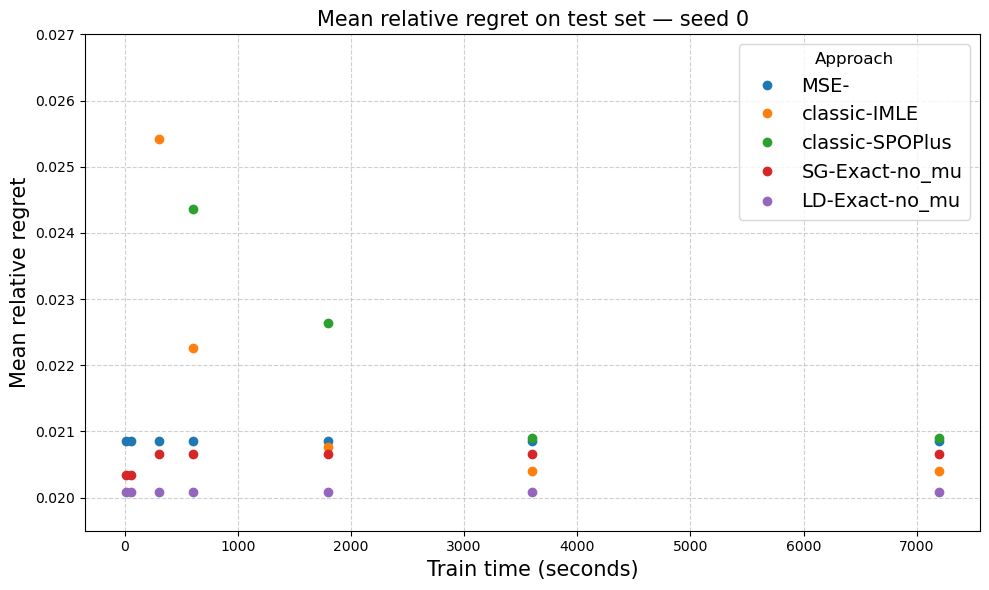

In [4]:
# ─── 5) Triplets à tracer ─────────────────────────────────────────────
selected = [
    ("MSE",     "",         True),
    ("classic", "IMLE",     True),
    ("classic", "SPOPlus",  True),
    ("SG",      "Exact",    False),
    ("LD",      "Exact",  False),
]

# ─── 6) Tracé (seed 0, sans IC) ───────────────────────────────────────
plt.figure(figsize=(10, 6))

for jt, meth, mu in selected:
    grp = (
        plot_df
        [(plot_df["jobtype"] == jt) &
         (plot_df["method"]  == meth) &
         (plot_df["muloss"]  == mu)]
        .sort_values("cp")
    )
    if grp.empty:
        print(f"⚠️ Aucun point pour le triplet {(jt, meth, mu)}")
        continue

    if jt in ("LD", "SG"):
        label = f"{jt}-{meth}{'-no_mu' if not mu else '-with_mu'}"
    else:
        label = f"{jt}-{meth}"

    plt.plot(
        grp["cp"],
        grp["mean_relat_test"],
        "o",              # points + tirets, pas d'IC
        label=label
    )

plt.xlabel("Train time (seconds)", fontsize=15)
plt.ylabel("Mean relative regret", fontsize=15)
plt.ylim(0.0195, 0.027)   # ajuste si nécessaire
plt.title("Mean relative regret on test set — seed 0", fontsize=15)
plt.legend(title="Approach", loc="best", frameon=True, fontsize=14, title_fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [5]:
import os
import pandas as pd

# ------------------------------------------------------------------
# 2) Dictionnaires utilitaires
# ------------------------------------------------------------------
EP_SUFFIX = {
    "classic": "cla",
    "cla":     "cla",
    "LD":      "ld",
    "SG":      "sg",
    "mse":     "mse",
    "MSE":     "mse",
}
NAME_SUFFIX = {
    "classic": "cla",
    "cla":     "cla",
    "LD":      "LD",
    "SG":      "SG",
    "mse":     "mse",
    "MSE":     "mse",
}

JOB_DIR = "portfolio/jobs_200"
os.makedirs(JOB_DIR, exist_ok=True)

# ------------------------------------------------------------------
# 3) Conversion lr float → chaîne "0p0001"
# ------------------------------------------------------------------
def lr_to_str(lr: float) -> str:
    return str(lr).replace(".", "p")

# ------------------------------------------------------------------
# 4) Génération des scripts SLURM pour seeds 0 à 9
# ------------------------------------------------------------------
for _, row in best_params.iterrows():
    n         = row.get("n", 200)
    jobtype   = str(row["jobtype"])
    method    = str(row["method"]).strip()
    muloss    = row.get("muloss", True)
    lr        = row["lr"]
    step_mu   = int(row.get("step_mu", 0))
    n_iter_mu = int(row.get("num_iter_mu", 0))

    # Pour MSE, on force la méthode à IMLE
    if jobtype.lower() == "mse":
        method = "IMLE"
    if method == "" or method.lower() == "nan":
        method = "Exact"

    # Construction des suffixes pour le nom
    jt_name = NAME_SUFFIX.get(jobtype, jobtype)
    lr_str  = lr_to_str(lr)

    # Cas step_mu / n_iter_mu
    extra_name = ""
    extra_args = ""
    if step_mu > 0 or n_iter_mu > 0:
        extra_name = f"_sm{step_mu}_ni{n_iter_mu}"
        extra_args = f" --step_mu {step_mu} --n_iter_mu {n_iter_mu}"

    # Argument --ep_*
    ep_suffix = EP_SUFFIX.get(jobtype, "")
    ep_arg    = f"--ep_{ep_suffix} 1000000" if ep_suffix else ""

    # Argument --muloss
    muloss_arg = "" if bool(muloss) else "--muloss 0"

    # Boucle sur les seeds 0 à 9
    for seed in range(10):
        # Nom du job SLURM incluant le seed
        job_name = f"portfolio_{jt_name}_{method}_n{n}{extra_name}_lr{lr_str}_seed{seed}"

        # Outfile variant selon le seed
        out_file = f"portfolio/n50/results_seed{seed}.csv"

        # Construction du script bash
        script = f"""#!/bin/bash
#SBATCH --time=34:00:00
#SBATCH --account=def-qcappart
#SBATCH --cpus-per-task=1
#SBATCH --mem=4G
#SBATCH --job-name={job_name}
#SBATCH --output=logs/{job_name}.out
#SBATCH --error=logs/{job_name}.err

module load StdEnv/2023 cuda/12.2 python/3.10 scipy-stack
source ~/env_projet/bin/activate

python -m portfolio.run_experiments \\
  --n {n} {ep_arg}{extra_args} \\
  --lr {lr} \\
  --method {method} \\
  --seed {seed} \\
  --report 10 60 300 600 1800 3600 7200 --num_eval_per_cp 100\\
  --out_file {out_file} \\
  {muloss_arg}
"""

        # Écriture du fichier .sh
        path = os.path.join(JOB_DIR, f"{job_name}.sh")
        with open(path, "w") as f:
            f.write(script)

        print(f"✓ Généré : {path}")

✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed0.sh
✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed1.sh
✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed2.sh
✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed3.sh
✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed4.sh
✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed5.sh
✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed6.sh
✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed7.sh
✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed8.sh
✓ Généré : portfolio/jobs_200/portfolio_mse_IMLE_n200_lr0p05_seed9.sh
✓ Généré : portfolio/jobs_200/portfolio_LD_Exact_n200_lr1p0_seed0.sh
✓ Généré : portfolio/jobs_200/portfolio_LD_Exact_n200_lr1p0_seed1.sh
✓ Généré : portfolio/jobs_200/portfolio_LD_Exact_n200_lr1p0_seed2.sh
✓ Généré : portfolio/jobs_200/portfolio_LD_Exact_n200_lr1p0_seed3.sh
✓ Généré : portfolio/job

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── 1) Extraire best_params depuis seed0 ─────────────────────────────
df0 = pd.read_csv("portfolio/n200/results_hyper_seed0.csv")
df0["method"]  = df0["method"].fillna("")
df0["jobtype"] = df0["jobtype"].fillna("")

best_idx = df0.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

best_params = df0.loc[best_idx, [
    "cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu"
]].reset_index(drop=True)

# ─── 2) Charger tous les résultats pour seeds 0–9 ──────────────────────
all_results = []
for seed in range(10):
    path = f"portfolio/n200/results_seed{seed}.csv"
    df = pd.read_csv(path)
    df["seed"]    = seed
    df["method"]  = df["method"].fillna("")
    df["jobtype"] = df["jobtype"].fillna("")
    all_results.append(df)
results = pd.concat(all_results, ignore_index=True)

# merge_cols défini comme avant
merge_cols = ["cp","method","jobtype","muloss","lr","step_mu","num_iter_mu"]

# 1) fusionner résultats et best_params
filtered_ = pd.merge(results, best_params, on=merge_cols, how="inner")

# 2) garder, pour chaque (merge_cols + seed), l'index du min mean_relat_test
idx_min = (
    filtered_
    .groupby(merge_cols + ["seed"])["mean_relat_test"]
    .idxmin()
)

# 3) extraire ces lignes uniques
filtered = filtered_.loc[idx_min].reset_index(drop=True)

# ─── 4) Calculer stats (mean, sem, ci95) par triplet et par cp ────────
stats = (
    filtered
    .groupby(["jobtype","method","muloss","cp"])["mean_relat_test"]
    .agg(mean="mean", sem="sem")
    .reset_index()
)
stats["ci95"] = 1.96 * stats["sem"]

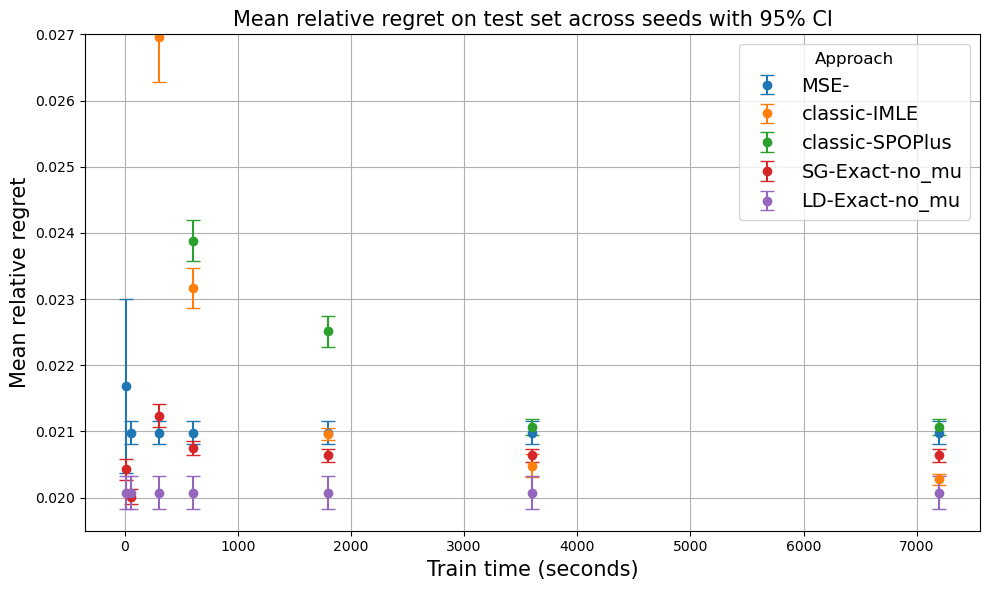

In [9]:
# ─── 5) Sélectionner les triplets à tracer ─────────────────────────────
# Exemple : on ne trace que deux configurations
selected = [
    ("MSE",    "",  True),
    ("classic", "IMLE", True),
    ("classic", "SPOPlus", True),
    #("LD",     "Exact", True),
    #("LD",    "Exact", False),
    #("SG",     "Exact", True),
    ("SG",    "Exact", False),
    ("LD", "Exact", False),
    #("SG", "SPOPlus", True),
    # ajoute ici autant de triplets que tu veux
]

# ─── 6) Tracer ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

for jt, meth, mu in selected:
    grp = stats[
        (stats["jobtype"] == jt) &
        (stats["method"]  == meth) &
        (stats["muloss"]  == mu)
    ]
    if grp.empty:
        print(f"⚠️ Aucun point pour le triplet {(jt, meth, mu)}")
        continue
    if jt in ("LD", "SG"):
        label = f"{jt}-{meth}{'-no_mu' if not mu else '-with_mu'}"
    else:
        label = f"{jt}-{meth}"
    plt.errorbar(
        grp["cp"],
        grp["mean"],
        yerr=grp["ci95"],
        fmt="o",      # marqueurs 'o' avec ligne en tirets
        capsize=5,
        label=label
    )

plt.xlabel("Train time (seconds)", fontsize=15)
plt.ylabel("Mean relative regret", fontsize=15)
plt.ylim(0.0195, 0.027)
plt.title("Mean relative regret on test set across seeds with 95% CI", fontsize=15)
plt.legend(
    title="Approach",
    loc="best",
    frameon=True,
    fontsize=14,
    title_fontsize=12
)
plt.grid(True)
plt.tight_layout()
plt.show()

# N=400

In [14]:
import pandas as pd

# 1. Charger votre CSV
df = pd.read_csv("portfolio/n400/results_hyper_seed0.csv")


# 2. S’assurer que les NaN de ‘method’ et ‘jobtype’ sont bien considérés comme des clés de groupe
df["method"]  = df["method"].fillna("")   # remplace NaN par chaîne vide
df["jobtype"] = df["jobtype"].fillna("")

# 3. Grouper par cp, method, jobtype, muloss (dropna=False pour inclure les NaN transformés)
best_idx = df.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

# 4. Extraire les hyper-paramètres optimaux pour chaque (cp, method, jobtype, muloss)
best_params = (
    df
    .loc[best_idx, ["cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu", "mean_relat_eval"]]
    .reset_index(drop=True)
)

print(best_params)

      cp   method  jobtype  muloss     lr  step_mu  num_iter_mu  \
0     10               MSE    True  0.005        0            0   
1     10    Exact       LD   False  0.010        0            0   
2     10    Exact       SG   False  1.000       15            1   
3     10     IMLE  classic    True  1.000        0            0   
4     10  SPOPlus  classic    True  0.010        0            0   
5     60               MSE    True  0.100        0            0   
6     60    Exact       LD   False  0.010        0            0   
7     60    Exact       SG   False  1.000       15            1   
8     60     IMLE  classic    True  1.000        0            0   
9     60  SPOPlus  classic    True  0.010        0            0   
10   300               MSE    True  0.100        0            0   
11   300    Exact       LD   False  0.010        0            0   
12   300    Exact       SG   False  1.000       15            1   
13   300     IMLE  classic    True  1.000        0            

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

BASE = "portfolio/n400"

# ─── 1) Extraire best_params depuis seed 0 ─────────────────────────────
df0 = pd.read_csv(f"{BASE}/results_hyper_seed0.csv")
df0["method"]  = df0["method"].fillna("")
df0["jobtype"] = df0["jobtype"].fillna("")

best_idx = df0.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

best_params = df0.loc[best_idx, [
    "cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu"
]].reset_index(drop=True)

# ─── 2) Charger SEULEMENT les résultats seed 0 ─────────────────────────
res0 = pd.read_csv(f"{BASE}/results_hyper_seed0.csv")
res0["method"]  = res0["method"].fillna("")
res0["jobtype"] = res0["jobtype"].fillna("")

# ─── 3) Filtrer sur les best_params ───────────────────────────────────
merge_cols = ["cp","method","jobtype","muloss","lr","step_mu","num_iter_mu"]
filtered_0 = pd.merge(res0, best_params, on=merge_cols, how="inner")

# Si plusieurs lignes existent pour la même config et le même cp,
# on garde la plus petite valeur de mean_relat_test.
idx_min = (
    filtered_0
    .groupby(merge_cols)["mean_relat_test"]
    .idxmin()
)
filtered_0 = filtered_0.loc[idx_min].reset_index(drop=True)

# ─── 4) Préparer les données de tracé : une ligne par triplet ─────────
# (pas d'IC : on ne calcule pas de moyenne/sem, on trace la valeur unique)
plot_df = filtered_0[["jobtype","method","muloss","cp","mean_relat_test"]].copy()

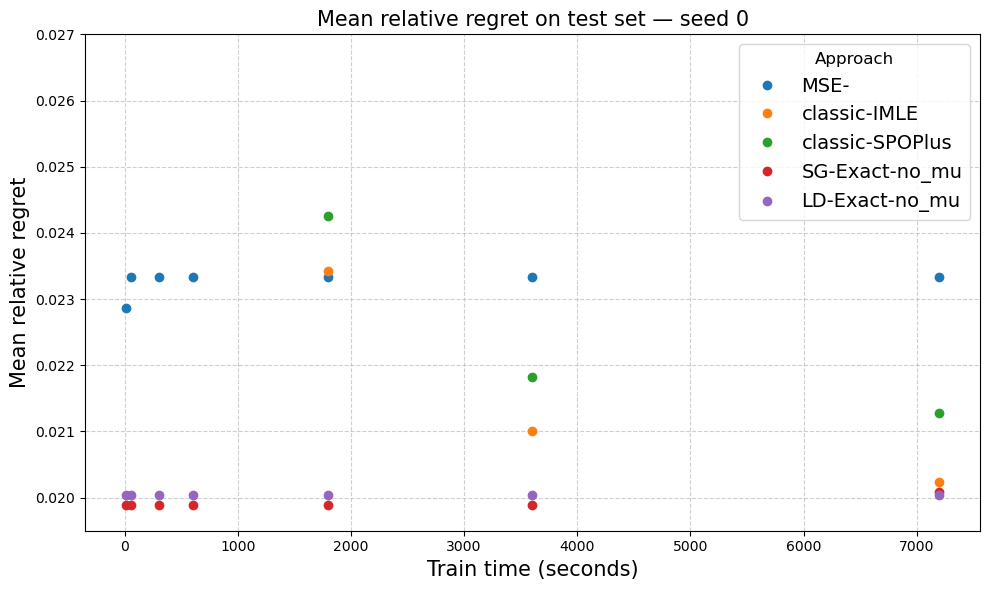

In [12]:
# ─── 5) Triplets à tracer ─────────────────────────────────────────────
selected = [
    ("MSE",     "",         True),
    ("classic", "IMLE",     True),
    ("classic", "SPOPlus",  True),
    ("SG",      "Exact",    False),
    ("LD",      "Exact",  False),
]

# ─── 6) Tracé (seed 0, sans IC) ───────────────────────────────────────
plt.figure(figsize=(10, 6))

for jt, meth, mu in selected:
    grp = (
        plot_df
        [(plot_df["jobtype"] == jt) &
         (plot_df["method"]  == meth) &
         (plot_df["muloss"]  == mu)]
        .sort_values("cp")
    )
    if grp.empty:
        print(f"⚠️ Aucun point pour le triplet {(jt, meth, mu)}")
        continue

    if jt in ("LD", "SG"):
        label = f"{jt}-{meth}{'-no_mu' if not mu else '-with_mu'}"
    else:
        label = f"{jt}-{meth}"

    plt.plot(
        grp["cp"],
        grp["mean_relat_test"],
        "o",              # points + tirets, pas d'IC
        label=label
    )

plt.xlabel("Train time (seconds)", fontsize=15)
plt.ylabel("Mean relative regret", fontsize=15)
plt.ylim(0.0195, 0.027)   # ajuste si nécessaire
plt.title("Mean relative regret on test set — seed 0", fontsize=15)
plt.legend(title="Approach", loc="best", frameon=True, fontsize=14, title_fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [17]:
import os
import pandas as pd

# ------------------------------------------------------------------
# 2) Dictionnaires utilitaires
# ------------------------------------------------------------------
EP_SUFFIX = {
    "classic": "cla",
    "cla":     "cla",
    "LD":      "ld",
    "SG":      "sg",
    "mse":     "mse",
    "MSE":     "mse",
}
NAME_SUFFIX = {
    "classic": "cla",
    "cla":     "cla",
    "LD":      "LD",
    "SG":      "SG",
    "mse":     "mse",
    "MSE":     "mse",
}

JOB_DIR = "portfolio/jobs_400"
os.makedirs(JOB_DIR, exist_ok=True)

# ------------------------------------------------------------------
# 3) Conversion lr float → chaîne "0p0001"
# ------------------------------------------------------------------
def lr_to_str(lr: float) -> str:
    return str(lr).replace(".", "p")

# ------------------------------------------------------------------
# 4) Génération des scripts SLURM pour seeds 0 à 9
# ------------------------------------------------------------------
for _, row in best_params.iterrows():
    n         = row.get("n", 400)
    jobtype   = str(row["jobtype"])
    method    = str(row["method"]).strip()
    muloss    = row.get("muloss", True)
    lr        = row["lr"]
    step_mu   = int(row.get("step_mu", 0))
    n_iter_mu = int(row.get("num_iter_mu", 0))

    # Pour MSE, on force la méthode à IMLE
    if jobtype.lower() == "mse":
        method = "IMLE"
    if method == "" or method.lower() == "nan":
        method = "Exact"

    # Construction des suffixes pour le nom
    jt_name = NAME_SUFFIX.get(jobtype, jobtype)
    lr_str  = lr_to_str(lr)

    # Cas step_mu / n_iter_mu
    extra_name = ""
    extra_args = ""
    if step_mu > 0 or n_iter_mu > 0:
        extra_name = f"_sm{step_mu}_ni{n_iter_mu}"
        extra_args = f" --step_mu {step_mu} --n_iter_mu {n_iter_mu}"

    # Argument --ep_*
    ep_suffix = EP_SUFFIX.get(jobtype, "")
    ep_arg    = f"--ep_{ep_suffix} 1000000" if ep_suffix else ""

    # Argument --muloss
    muloss_arg = "" if bool(muloss) else "--muloss 0"

    # Boucle sur les seeds 0 à 9
    for seed in range(10):
        # Nom du job SLURM incluant le seed
        job_name = f"portfolio_{jt_name}_{method}_n{n}{extra_name}_lr{lr_str}_seed{seed}"

        # Outfile variant selon le seed
        out_file = f"portfolio/n400/results_seed{seed}.csv"

        # Construction du script bash
        script = f"""#!/bin/bash
#SBATCH --time=82:00:00
#SBATCH --account=def-qcappart
#SBATCH --cpus-per-task=1
#SBATCH --mem=4G
#SBATCH --job-name={job_name}
#SBATCH --output=logs/{job_name}.out
#SBATCH --error=logs/{job_name}.err

module load StdEnv/2023 cuda/12.2 python/3.10 scipy-stack
module load gurobi
export LC_ALL=C
source ~/env_projet/bin/activate

python -m portfolio.run_experiments \\
  --n {n} {ep_arg}{extra_args} \\
  --lr {lr} \\
  --method {method} \\
  --seed {seed} \\
  --report 10 60 300 600 1800 3600 7200 --num_eval_per_cp 100\\
  --out_file {out_file} \\
  {muloss_arg}
"""

        # Écriture du fichier .sh
        path = os.path.join(JOB_DIR, f"{job_name}.sh")
        with open(path, "w") as f:
            f.write(script)

        print(f"✓ Généré : {path}")

✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed0.sh
✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed1.sh
✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed2.sh
✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed3.sh
✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed4.sh
✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed5.sh
✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed6.sh
✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed7.sh
✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed8.sh
✓ Généré : portfolio/jobs_400/portfolio_mse_IMLE_n400_lr0p005_seed9.sh
✓ Généré : portfolio/jobs_400/portfolio_LD_Exact_n400_lr0p01_seed0.sh
✓ Généré : portfolio/jobs_400/portfolio_LD_Exact_n400_lr0p01_seed1.sh
✓ Généré : portfolio/jobs_400/portfolio_LD_Exact_n400_lr0p01_seed2.sh
✓ Généré : portfolio/jobs_400/portfolio_LD_Exact_n400_lr0p01_seed3.sh
✓ Généré :

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── 1) Extraire best_params depuis seed0 ─────────────────────────────
df0 = pd.read_csv("portfolio/n400/results_hyper_seed0.csv")
df0["method"]  = df0["method"].fillna("")
df0["jobtype"] = df0["jobtype"].fillna("")

best_idx = df0.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

best_params = df0.loc[best_idx, [
    "cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu"
]].reset_index(drop=True)

# ─── 2) Charger tous les résultats pour seeds 0–9 ──────────────────────
all_results = []
for seed in range(10):
    path = f"portfolio/n400/results_seed{seed}.csv"
    df = pd.read_csv(path)
    df["seed"]    = seed
    df["method"]  = df["method"].fillna("")
    df["jobtype"] = df["jobtype"].fillna("")
    all_results.append(df)
results = pd.concat(all_results, ignore_index=True)

# merge_cols défini comme avant
merge_cols = ["cp","method","jobtype","muloss","lr","step_mu","num_iter_mu"]

# 1) fusionner résultats et best_params
filtered_ = pd.merge(results, best_params, on=merge_cols, how="inner")

# 2) garder, pour chaque (merge_cols + seed), l'index du min mean_relat_test
idx_min = (
    filtered_
    .groupby(merge_cols + ["seed"])["mean_relat_test"]
    .idxmin()
)

# 3) extraire ces lignes uniques
filtered = filtered_.loc[idx_min].reset_index(drop=True)

# ─── 4) Calculer stats (mean, sem, ci95) par triplet et par cp ────────
stats = (
    filtered
    .groupby(["jobtype","method","muloss","cp"])["mean_relat_test"]
    .agg(mean="mean", sem="sem")
    .reset_index()
)
stats["ci95"] = 1.96 * stats["sem"]

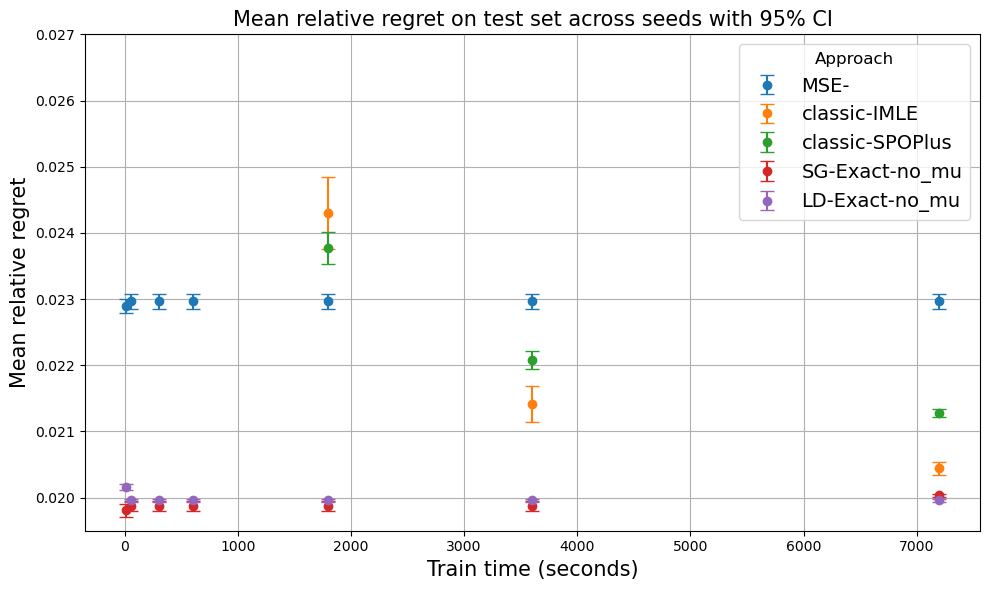

In [19]:
# ─── 5) Sélectionner les triplets à tracer ─────────────────────────────
# Exemple : on ne trace que deux configurations
selected = [
    ("MSE",    "",  True),
    ("classic", "IMLE", True),
    ("classic", "SPOPlus", True),
    #("LD",     "Exact", True),
    #("LD",    "Exact", False),
    #("SG",     "Exact", True),
    ("SG",    "Exact", False),
    ("LD", "Exact", False),
    #("SG", "SPOPlus", True),
    # ajoute ici autant de triplets que tu veux
]

# ─── 6) Tracer ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

for jt, meth, mu in selected:
    grp = stats[
        (stats["jobtype"] == jt) &
        (stats["method"]  == meth) &
        (stats["muloss"]  == mu)
    ]
    if grp.empty:
        print(f"⚠️ Aucun point pour le triplet {(jt, meth, mu)}")
        continue
    if jt in ("LD", "SG"):
        label = f"{jt}-{meth}{'-no_mu' if not mu else '-with_mu'}"
    else:
        label = f"{jt}-{meth}"
    plt.errorbar(
        grp["cp"],
        grp["mean"],
        yerr=grp["ci95"],
        fmt="o",      # marqueurs 'o' avec ligne en tirets
        capsize=5,
        label=label
    )

plt.xlabel("Train time (seconds)", fontsize=15)
plt.ylabel("Mean relative regret", fontsize=15)
plt.ylim(0.0195, 0.027)
plt.title("Mean relative regret on test set across seeds with 95% CI", fontsize=15)
plt.legend(
    title="Approach",
    loc="best",
    frameon=True,
    fontsize=14,
    title_fontsize=12
)
plt.grid(True)
plt.tight_layout()
plt.show()

⚠️ Aucun point pour le triplet ('LD', 'SPOPlus', True)


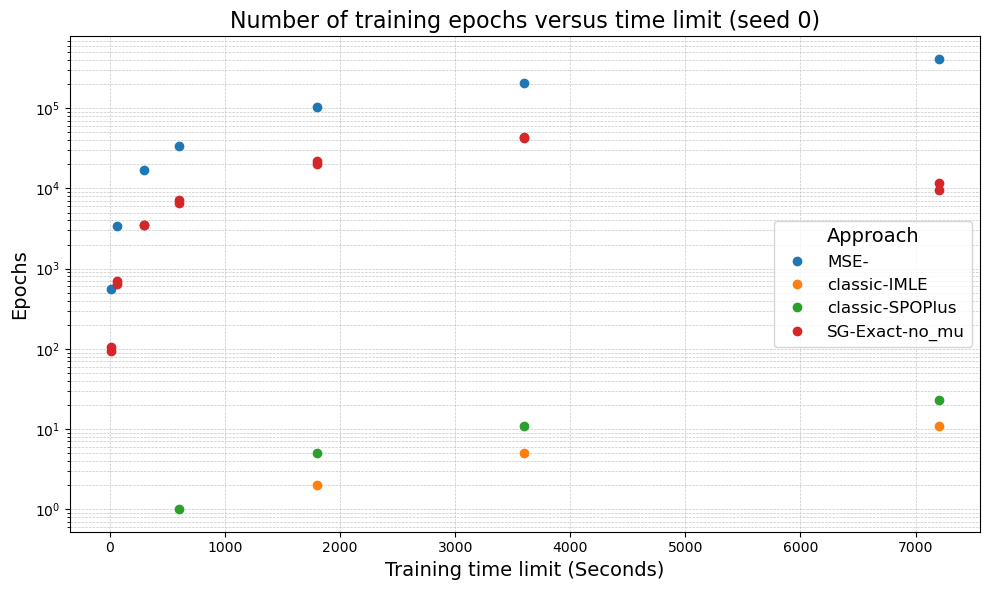

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# ─── 1) Extraire best_params depuis results_hyper_seed0.csv ───────────
df0 = pd.read_csv("portfolio/n400/results_hyper_seed0.csv")
df0["method"]  = df0["method"].fillna("")
df0["jobtype"] = df0["jobtype"].fillna("")

best_idx = df0.groupby(
    ["cp", "method", "jobtype", "muloss"],
    dropna=False
)["mean_relat_eval"].idxmin()

best_params = df0.loc[best_idx, [
    "cp", "method", "jobtype", "muloss", "lr", "step_mu", "num_iter_mu"
]].reset_index(drop=True)

# ─── 2) Charger les résultats pour seed 0 ──────────────────────────────
df_seed0 = pd.read_csv("portfolio/n400/results_seed0.csv")
df_seed0["method"]  = df_seed0["method"].fillna("")
df_seed0["jobtype"] = df_seed0["jobtype"].fillna("")

# ─── 3) Filtrer seed0 sur les meilleures configs ───────────────────────
merge_cols = ["cp","method","jobtype","muloss","lr","step_mu","num_iter_mu"]
filtered0 = pd.merge(df_seed0, best_params, on=merge_cols, how="inner")

# ─── 4) Définir les triplets à tracer ──────────────────────────────────
selected = [
    ("MSE",    "",  True),
    ("classic", "IMLE", True),
    ("classic", "SPOPlus", True),
    #("LD",     "Exact", True),
    #("LD",    "Exact", False),
    #("SG",     "Exact", True),
    ("SG",    "Exact", False),
    ("LD", "SPOPlus", True),
    #("SG", "SPOPlus", True),
    # ajoute ici autant de triplets que tu veux
]

# ─── 5) Tracer epoch vs train time pour seed 0 ────────────────────────
plt.figure(figsize=(10, 6))

for jt, meth, mu in selected:
    grp = filtered0[
        (filtered0["jobtype"] == jt) &
        (filtered0["method"]  == meth) &
        (filtered0["muloss"]  == mu)
    ]
    if grp.empty:
        print(f"⚠️ Aucun point pour le triplet {(jt, meth, mu)}")
        continue

    if jt in ("LD", "SG"):
        label = f"{jt}-{meth}{'-no_mu' if not mu else '-with_mu'}"
    else:
        label = f"{jt}-{meth}"

    plt.plot(
        grp["cp"],
        grp["epoch"],
        marker="o",
        linestyle="",
        label=label
    )

plt.xlabel("Training time limit (Seconds)", fontsize=14)
plt.ylabel("Epochs",          fontsize=14)
plt.title("Number of training epochs versus time limit (seed 0)", fontsize=16)

# Légende à l’intérieur
leg = plt.legend(title="Approach", loc="best", frameon=True, fontsize=12)
leg.get_title().set_fontsize(14)
plt.yscale('log')

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()